In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [34]:
import warnings

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries
from darts.metrics import r2_score
from darts.models.forecasting.xlstm_mixer import xLSTMMixer

In [17]:
def display_forecast(pred_series, ts_transformed, forecast_type, start_date=None):
    plt.figure(figsize=(8, 5))
    if start_date:
        ts_transformed = ts_transformed.drop_before(start_date)
    ts_transformed.univariate_component(0).plot(label="actual")
    pred_series.plot(label=("historic " + forecast_type + " forecasts"))
    plt.title(f"R2: {r2_score(ts_transformed.univariate_component(0), pred_series)}")
    plt.legend()

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

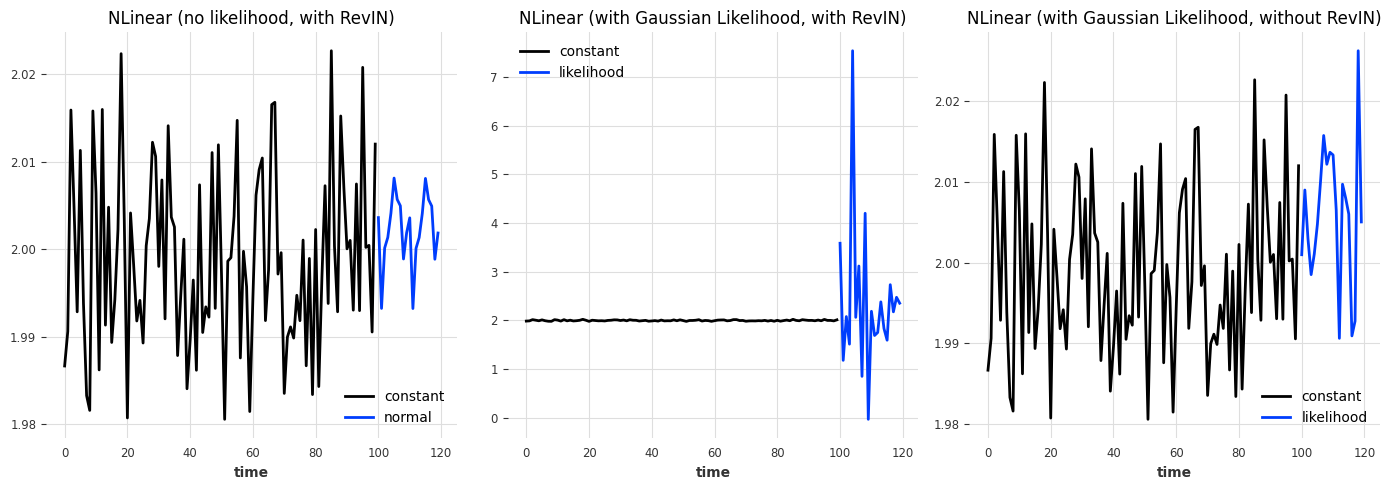

In [36]:
from darts.models import NLinearModel
from darts.utils.likelihood_models import GaussianLikelihood

# Constant TS creation
constant_two = np.ones(100) * 2 + np.random.normal(0, 0.01, 100)
constant_two_series = TimeSeries.from_values(constant_two).astype(np.float32)

# Create normal model without likelihood and with reversible instance norm
model_normal = NLinearModel(20, 10, use_reversible_instance_norm=False)
model_normal.fit(constant_two_series)
normal_pred_series = model_normal.predict(20, series=constant_two_series)


# Create model with likelihood and with reversible instance norm
model_likelihood_with_revin = NLinearModel(
    20, 10, use_reversible_instance_norm=True, likelihood=GaussianLikelihood()
)
model_likelihood_with_revin.fit(constant_two_series)
likelihood_with_revin_pred_series = model_likelihood_with_revin.predict(
    20, series=constant_two_series
)

# Create model with likelihood and with reversible instance norm
model_likelihood = NLinearModel(
    20, 10, use_reversible_instance_norm=False, likelihood=GaussianLikelihood()
)
model_likelihood.fit(constant_two_series)
likelihood_pred_series = model_likelihood.predict(20, series=constant_two_series)

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))  # 1 row, 2 columns

# Left plot: Normal model
constant_two_series.plot(ax=axes[0], label="constant")
normal_pred_series.plot(ax=axes[0], label="normal")
axes[0].set_title("NLinear (no likelihood, with RevIN)")
axes[0].legend()

# Right plot: Likelihood model
constant_two_series.plot(ax=axes[1], label="constant")
likelihood_with_revin_pred_series.plot(ax=axes[1], label="likelihood")
axes[1].set_title("NLinear (with Gaussian Likelihood, with RevIN)")
axes[1].legend()

# Right plot: Likelihood model
constant_two_series.plot(ax=axes[2], label="constant")
likelihood_pred_series.plot(ax=axes[2], label="likelihood")
axes[2].set_title("NLinear (with Gaussian Likelihood, without RevIN)")
axes[2].legend()


plt.tight_layout()
plt.show()

In [ ]:
import torch

model = xLSTMMixer(
    input_chunk_length=16,
    output_chunk_length=4,
    likelihood=None,  # Or None, neither works
)
# make a syntehtic time series for testing (10000 steps, 15 variates)
ts = TimeSeries.from_times_and_values(
    pd.date_range("2020-01-01", periods=10000, freq="D"),
    torch.randn(10000, 15),
)
model.fit(ts, verbose=True, epochs=1)

Training: |          | 0/? [00:00<?, ?it/s]

torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch.Size([32, 15, 512])
After FC: torch.Size([32, 15, 4])
Return Shape: torch.Size([32, 4, 15, 1])
torch.Size([32, 16, 15])
Before FC: torch

xLSTMMixer(output_chunk_shift=0, xlstm_embedding_dim=256, num_mem_tokens=1, num_tokens_per_variate=1, xlstm_dropout=0.2, xlstm_conv1d_kernel_size=4, xlstm_num_heads=8, xlstm_num_blocks=2, use_mlstm=False, use_reversible_instance_norm=False, packing=1, backbone=nlinear, input_chunk_length=16, output_chunk_length=4, likelihood=None)